In [122]:
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [222]:
config_id = 23
filename = f"_outputs/metrics-{config_id}.h5"

with h5py.File(filename, "r") as store:
    site_msds = store["site_msds"][:] 
    separation_scores = store["separation_scores"][:]
    separation_histories = store["separation_histories"][:]

with open(f"config-{config_id}.json", "r") as file:
    config = json.load(file)

In [223]:
sampling_config = config["sampling"]
phase_overrides = sampling_config["phases"][-1]
phase_config = {**sampling_config, **phase_overrides}
frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

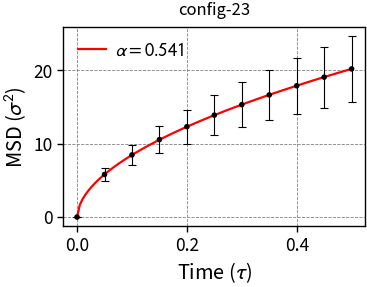

In [224]:
lags = np.arange(site_msds.shape[1]) * frame_interval
msd_samples = einops.rearrange(site_msds, "r t s -> (r s) t")
msd_mean = msd_samples.mean(axis=0)
msd_std = msd_samples.std(axis=0)
y_scale = 1

#x = np.tile(lags, msd_samples.shape[0])
#y = msd_samples.flatten()
x = lags
y = msd_mean
alpha, beta = fit_power_law(x, y)

fig, ax = plt.subplots(figsize=(1.9, 1.5))

x = lags
y = msd_mean * y_scale
y_err = msd_std * y_scale
ax.errorbar(x, y, y_err, color="k", linewidth=0, elinewidth=0.4, capsize=1.3, capthick=0.4, zorder=2)
ax.scatter(x, y, s=4, ec="none", fc="k", zorder=3)

x = np.linspace(lags[0], lags[-1], num=100)
y = x**alpha * beta * y_scale
s = r"$ \alpha = %.3g $" % alpha
ax.plot(x, y, lw=0.8, color="r", label=s)

ax.grid(True, zorder=1)
ax.legend()
ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"config-{config_id}", fontsize="small")

pass

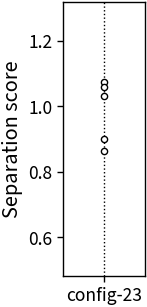

In [225]:
fig, ax = plt.subplots(figsize=(0.8, 1.6))

x = np.full_like(separation_scores, 1)
y = separation_scores
ax.scatter(x, y, s=5, ec="k", fc="w", zorder=2)
ax.axvline(1, ls=":", zorder=1)

ax.set_ylim(0.48, 1.32)
ax.set_xticks([1])
ax.set_xticklabels([f"config-{config_id}"])
ax.set_ylabel("Separation score")

pass

In [226]:
orders = np.argsort(separation_scores)
median_instance = orders[len(orders) // 2]
median_instance + 1

2

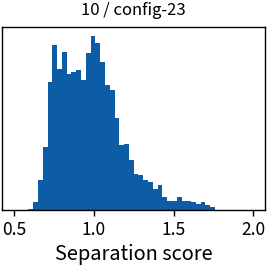

In [227]:
score_bins = np.linspace(0.5, 2.0, num=51)

fig, ax = plt.subplots(figsize=(1.4, 1.4))

ax.hist(separation_histories.ravel(), bins=score_bins)

ax.set_xlabel("Separation score")
ax.set_yticks([])
ax.set_title(f"10 / config-{config_id}", fontsize="small")

pass